In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/deliveries.csv')

In [ ]:
df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [ ]:
df.shape

(260920, 17)

In [ ]:
df.dtypes

,0
match_id,int64
inning,int64
batting_team,object
bowling_team,object
over,int64
ball,int64
batter,object
bowler,object
non_striker,object
batsman_runs,int64


In [ ]:
df.describe()

,match_id,inning,over,ball,batsman_runs,extra_runs,total_runs,is_wicket
count,2.609200e+05,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000
mean,9.070665e+05,1.483531,9.197677,3.624486,1.265001,0.067806,1.332807,0.049632
std,3.679913e+05,0.502643,5.683484,1.814920,1.639298,0.343265,1.626416,0.217184
min,3.359820e+05,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,5.483340e+05,1.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,9.809670e+05,1.000000,9.000000,4.000000,1.000000,0.000000,1.000000,0.000000
75%,1.254066e+06,2.000000,14.000000,5.000000,1.000000,0.000000,1.000000,0.000000
max,1.426312e+06,6.000000,19.000000,11.000000,6.000000,7.000000,7.000000,1.000000


In [ ]:
df.isnull()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True
1,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,True,True
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True
3,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,True,True
4,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260915,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,True,True
260916,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,True,True
260917,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,True,True
260918,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,True,True


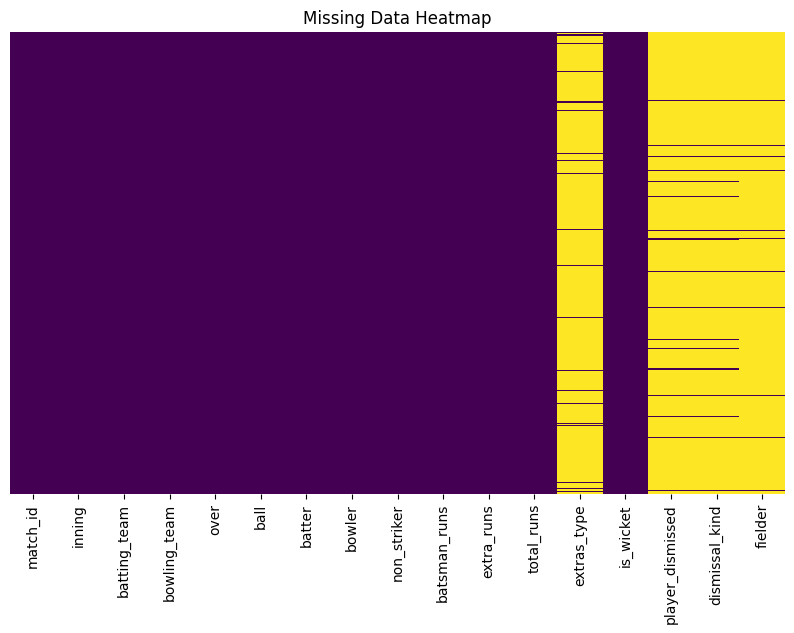

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

In [ ]:
fill_cols = ['extras_type', 'player_dismissed', 'dismissal_kind', 'fielder']
df[fill_cols] = df[fill_cols].fillna('none')

# Only these 4 columns contain missing values
# For extras type: Dropping the column would lose useful signal for models that care about extras; dropping rows would remove 94 % of the dataset — both are wrong.
# Similar for player_dismissed as well
# dismissal_kind is correlated to player_dismissed so can't drop it
# Similar for fielder as it would make us lose useful signals

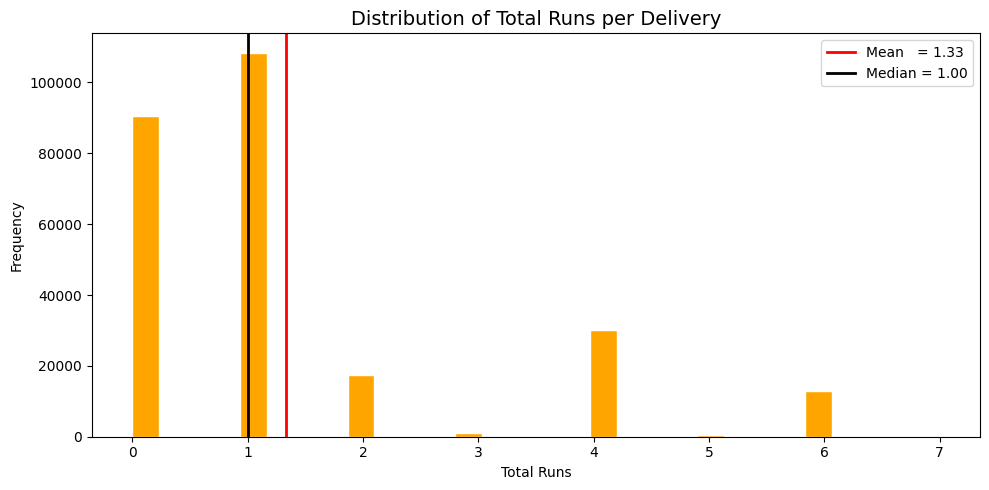

In [ ]:
runs = df['total_runs']

mean_val   = runs.mean()
median_val = runs.median()

plt.figure(figsize=(10, 5))
plt.hist(runs, bins = 30, color='orange', edgecolor='white')

plt.axvline(mean_val, color = 'red', lw = 2, label=f'Mean   = {mean_val:.2f}')
plt.axvline(median_val, color = 'black', lw = 2, label=f'Median = {median_val:.2f}')

plt.title('Distribution of Total Runs per Delivery', fontsize=14)
plt.xlabel('Total Runs')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# This dataset is right skewed since the Mean value is more than Median

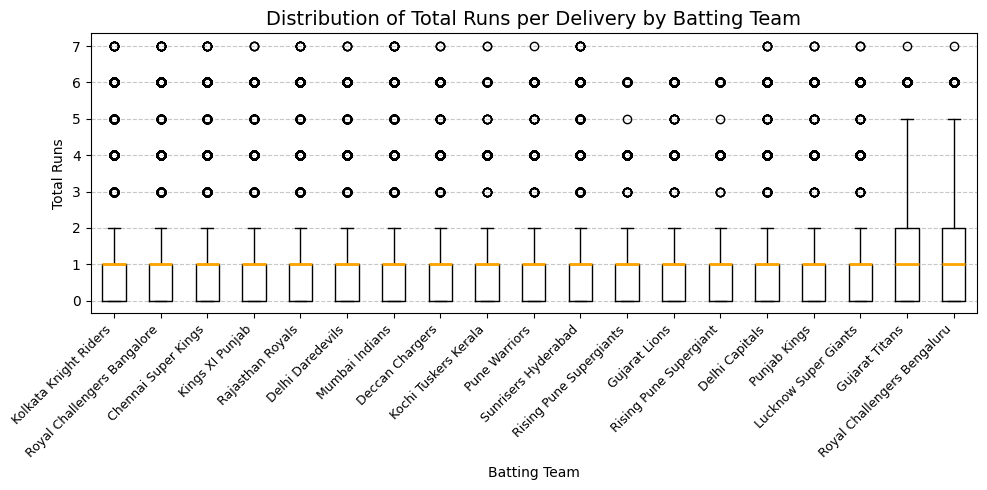

In [ ]:
teams = df['batting_team'].unique()
grouped = [df[df['batting_team'] == team]['total_runs'].values for team in teams]

fig, ax = plt.subplots(figsize=(10, 5))

bp = ax.boxplot(grouped, medianprops=dict(color='orange', linewidth=2))

ax.set_xticklabels(teams, rotation=45, ha='right', fontsize=9)
ax.set_title('Distribution of Total Runs per Delivery by Batting Team', fontsize=14)
ax.set_xlabel('Batting Team')
ax.set_ylabel('Total Runs')
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Batting Team')

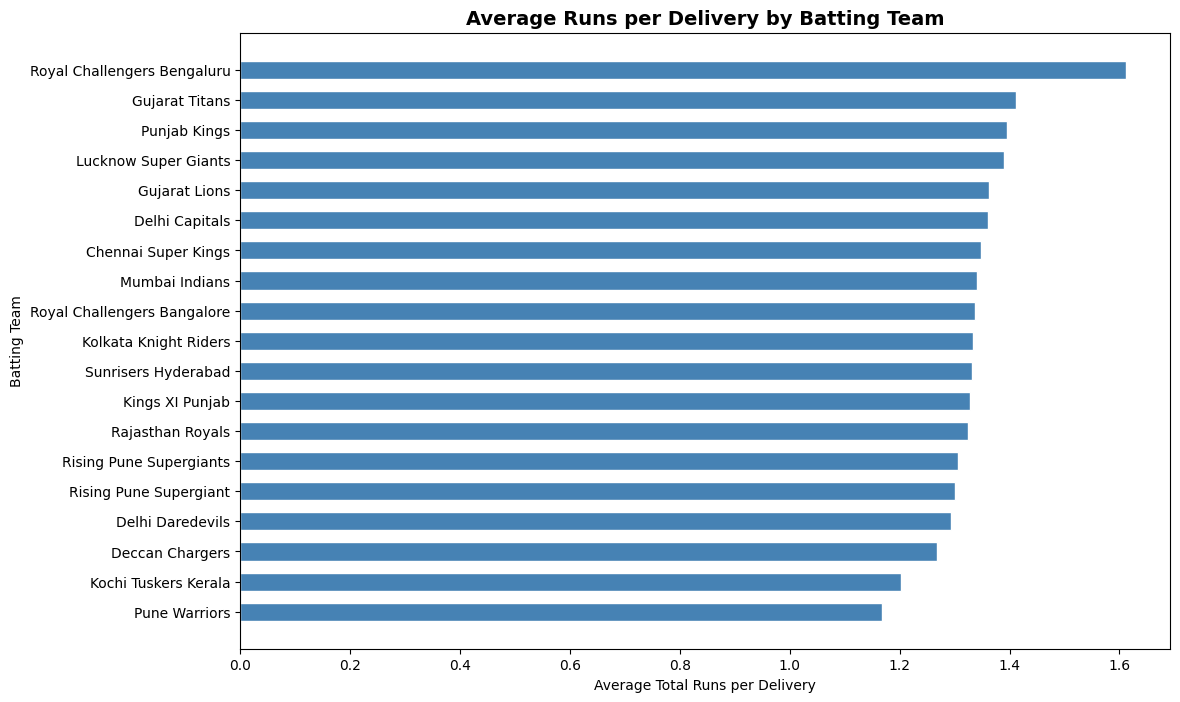

In [ ]:
team_avg = (df.groupby('batting_team')['total_runs'].mean().sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(team_avg.index, team_avg.values, color='steelblue', edgecolor='white', height=0.6)

ax.set_title('Average Runs per Delivery by Batting Team', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Total Runs per Delivery')
ax.set_ylabel('Batting Team')


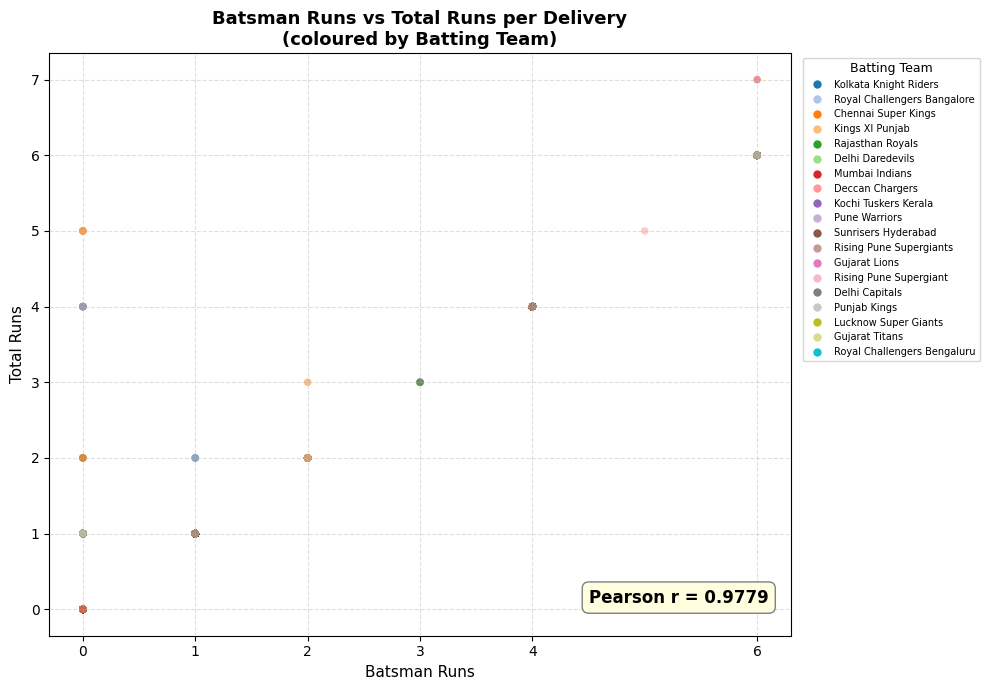

Pearson r = 0.9779
r²        = 0.9564  (95.6% of variance explained)


In [ ]:
x = df['batsman_runs']
y = df['total_runs']

# Pearson correlation
corr = np.corrcoef(x, y)[0, 1]

# Map each batting team to a colour
teams = df['batting_team'].unique()
palette = plt.cm.tab20.colors
team_colour = {team: palette[i % 20] for i, team in enumerate(teams)}
colours = df['batting_team'].map(team_colour)

fig, ax = plt.subplots(figsize=(10, 7))

sample = df.sample(3000, random_state=42)
sample_colours = sample['batting_team'].map(team_colour)

ax.scatter(sample['batsman_runs'], sample['total_runs'],
           c=sample_colours, alpha=0.5, edgecolors='none', s=30)

ax.text(0.97, 0.05, f'Pearson r = {corr:.4f}',
        transform=ax.transAxes, fontsize=12, fontweight='bold',
        ha='right', va='bottom',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='grey'))

handles = [plt.Line2D([0], [0], marker='o', color='w',
                       markerfacecolor=team_colour[t], markersize=7, label=t)
           for t in teams]
ax.legend(handles=handles, title='Batting Team', bbox_to_anchor=(1.01, 1),
          loc='upper left', fontsize=7, title_fontsize=9)

ax.set_title('Batsman Runs vs Total Runs per Delivery\n(coloured by Batting Team)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Batsman Runs', fontsize=11)
ax.set_ylabel('Total Runs', fontsize=11)
ax.set_xticks([0, 1, 2, 3, 4, 6])
ax.set_yticks(sorted(df['total_runs'].unique()))
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f'Pearson r = {corr:.4f}')
print(f'r²        = {corr**2:.4f}  ({corr**2*100:.1f}% of variance explained)')

#NOTE: I WAS FACING SOME DIFFICULTIES IN PLOTTING THIS AND IN THE END I HAVE USED AI TO DO SO

[Text(0, 0, 'match_id'),
 Text(0, 1, 'inning'),
 Text(0, 2, 'over'),
 Text(0, 3, 'ball'),
 Text(0, 4, 'batsman_runs'),
 Text(0, 5, 'extra_runs'),
 Text(0, 6, 'total_runs'),
 Text(0, 7, 'is_wicket')]

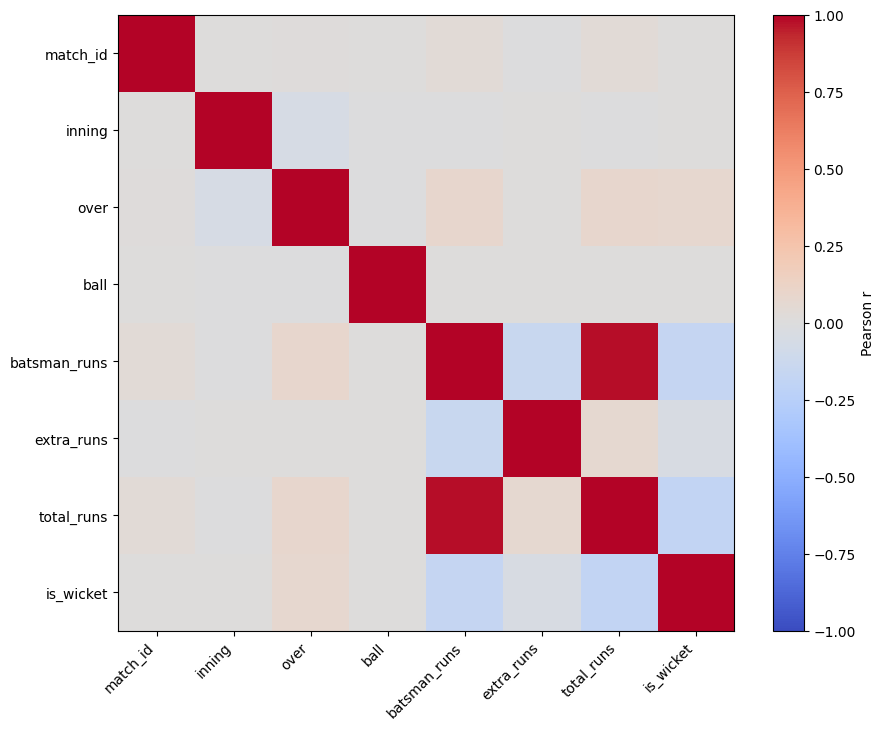

In [58]:
corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Pearson r')

cols = corr.columns
ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha='right')
ax.set_yticklabels(cols)

In [59]:
# STRONGEST CORRELATION: batsman_runs and total_runs
# WEAKEST CORRELATION: over and batsman_runs; inning and extra_run

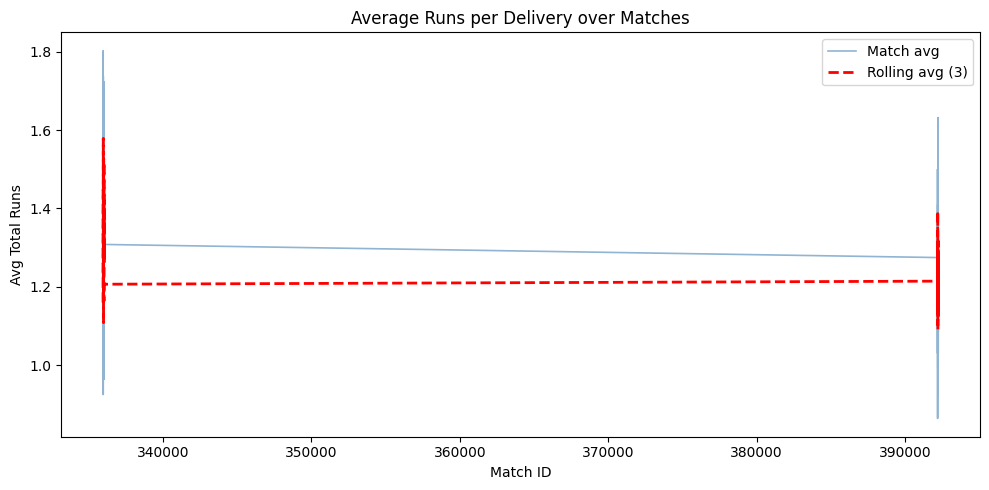

In [61]:
trend = df.groupby('match_id')['total_runs'].mean().reset_index()
trend.columns = ['match_id', 'avg_runs']
trend = trend.sort_values('match_id').head(100)

rolling = trend['avg_runs'].rolling(window=3).mean()

plt.figure(figsize=(10, 5))
plt.plot(trend['match_id'], trend['avg_runs'], color='steelblue', alpha=0.6, linewidth=1.2, label='Match avg')
plt.plot(trend['match_id'], rolling, color='red', linestyle='--', linewidth=2, label='Rolling avg (3)')
plt.title('Average Runs per Delivery over Matches')
plt.xlabel('Match ID')
plt.ylabel('Avg Total Runs')
plt.legend()
plt.tight_layout()
plt.show()


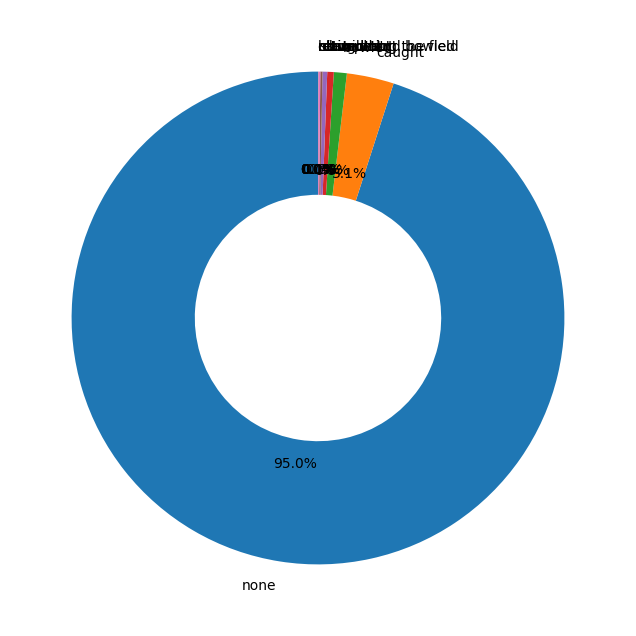

In [64]:
counts = df['dismissal_kind'].value_counts().dropna()

fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    wedgeprops={'width': 0.5},
    startangle=90
)

In [65]:
# BAR CHART SHOULD BE USED WHEN WE HAVE A LARGE NUMBER OF CATEGORIES TO PLOT
# IN CASE OF A DONUT, WHEN THE NUMBER OF SLICES IS LARGE THE WEDGES BECOME DIFFICULT TO READ AND THE PERCENTAGES AND LABELS OVERLAP

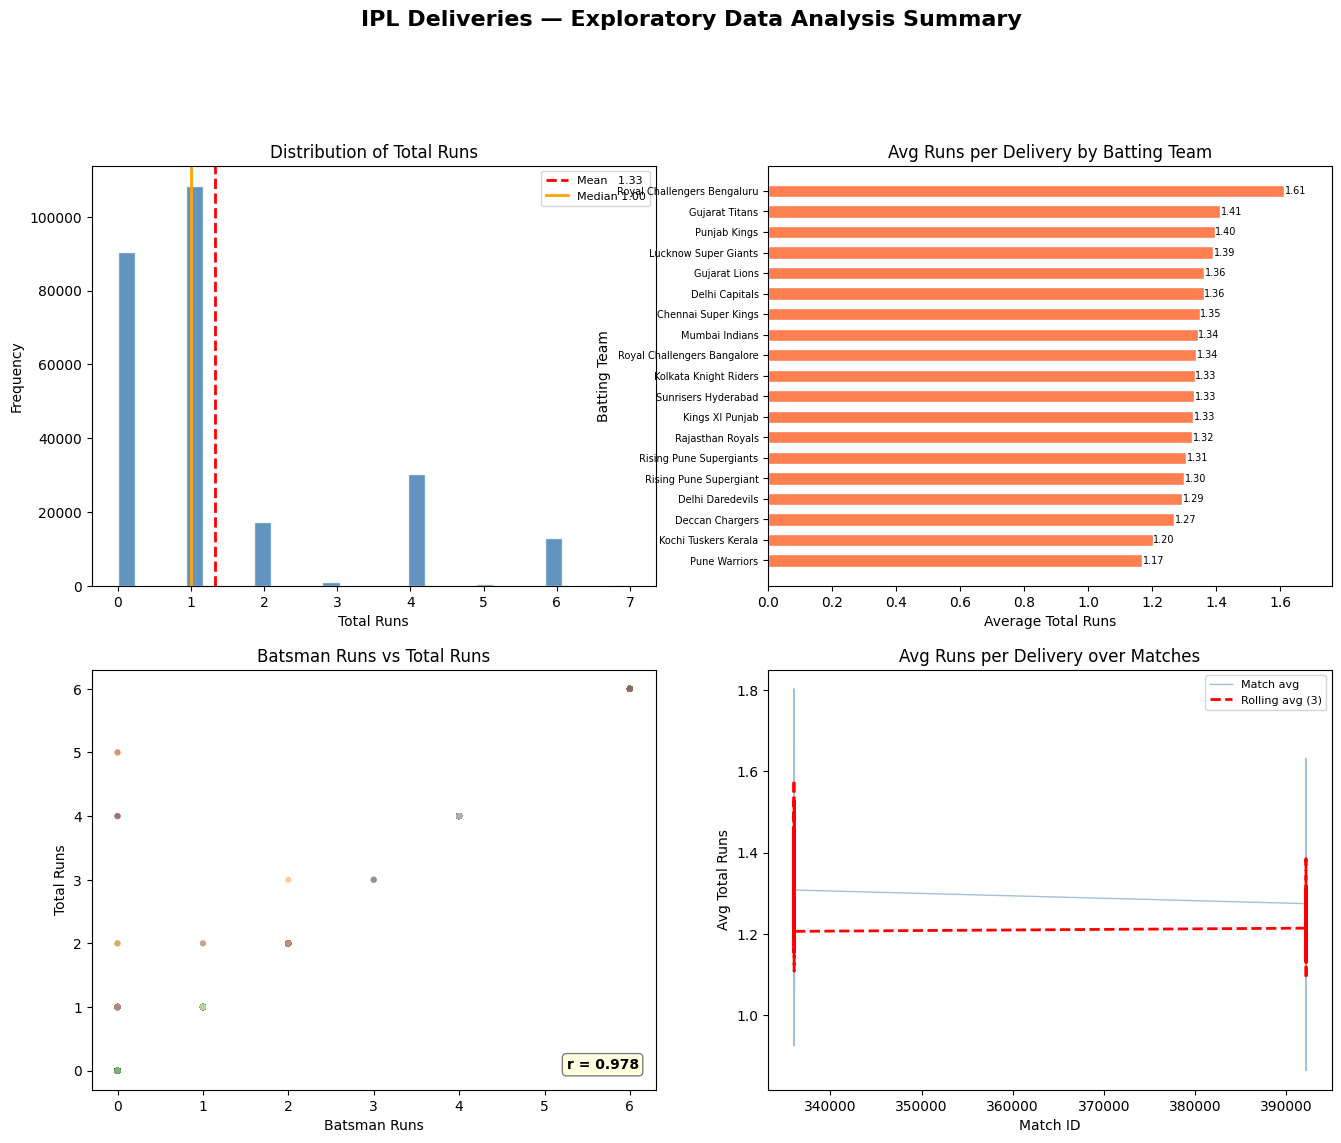

In [68]:
# I HAVE GENERATED THESE GRAPHS USING AI TO COMPARE WITH THE GRAPHS I OBTAINED; GIVEN IN THE NEXT CELL ARE THE GRAPHS THAT I MANUALLY PLOTTED

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('IPL Deliveries — Exploratory Data Analysis Summary', fontsize=16, fontweight='bold', y=1.01)

# ── 1. Histogram: Distribution of total runs ─────────────────────────────────
ax = axes[0, 0]
data = df['total_runs']
ax.hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(data.mean(),   color='red',    linestyle='--', linewidth=2, label=f'Mean   {data.mean():.2f}')
ax.axvline(data.median(), color='orange', linestyle='-',  linewidth=2, label=f'Median {data.median():.2f}')
ax.set_title('Distribution of Total Runs')
ax.set_xlabel('Total Runs')
ax.set_ylabel('Frequency')
ax.legend(fontsize=8)

# ── 2. Horizontal bar: Avg runs per batting team ─────────────────────────────
ax = axes[0, 1]
team_avg = df.groupby('batting_team')['total_runs'].mean().sort_values(ascending=True)
bars = ax.barh(team_avg.index, team_avg.values, color='coral', edgecolor='white', height=0.6)
for bar, val in zip(bars, team_avg.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', ha='left', fontsize=7)
ax.set_title('Avg Runs per Delivery by Batting Team')
ax.set_xlabel('Average Total Runs')
ax.set_ylabel('Batting Team')
ax.tick_params(axis='y', labelsize=7)
ax.set_xlim(0, team_avg.max() + 0.15)

# ── 3. Scatter: Batsman runs vs total runs ───────────────────────────────────
ax = axes[1, 0]
sample = df.sample(2000, random_state=42)
teams  = df['batting_team'].unique()
palette = plt.cm.tab20.colors
team_colour = {t: palette[i % 20] for i, t in enumerate(teams)}
colours = sample['batting_team'].map(team_colour)
ax.scatter(sample['batsman_runs'], sample['total_runs'],
           c=colours, alpha=0.4, edgecolors='none', s=20)
corr = np.corrcoef(df['batsman_runs'], df['total_runs'])[0, 1]
ax.text(0.97, 0.05, f'r = {corr:.3f}', transform=ax.transAxes,
        fontsize=10, fontweight='bold', ha='right',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='grey'))
ax.set_title('Batsman Runs vs Total Runs')
ax.set_xlabel('Batsman Runs')
ax.set_ylabel('Total Runs')

# ── 4. Line: Avg runs per match with rolling average ────────────────────────
ax = axes[1, 1]
trend   = df.groupby('match_id')['total_runs'].mean().reset_index().sort_values('match_id').head(100)
rolling = trend['total_runs'].rolling(window=3).mean()
ax.plot(trend['match_id'], trend['total_runs'], color='steelblue', alpha=0.5, linewidth=1, label='Match avg')
ax.plot(trend['match_id'], rolling,             color='red', linestyle='--', linewidth=2, label='Rolling avg (3)')
ax.set_title('Avg Runs per Delivery over Matches')
ax.set_xlabel('Match ID')
ax.set_ylabel('Avg Total Runs')
ax.legend(fontsize=8)

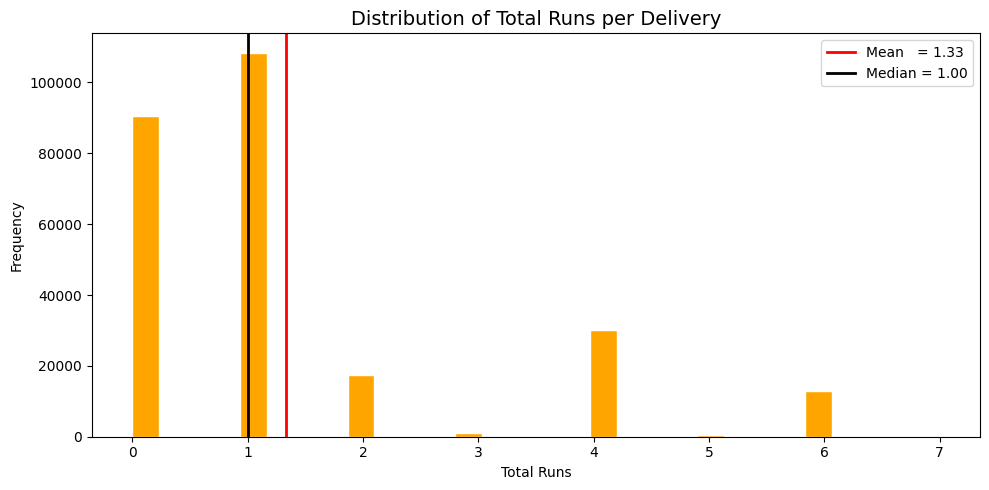

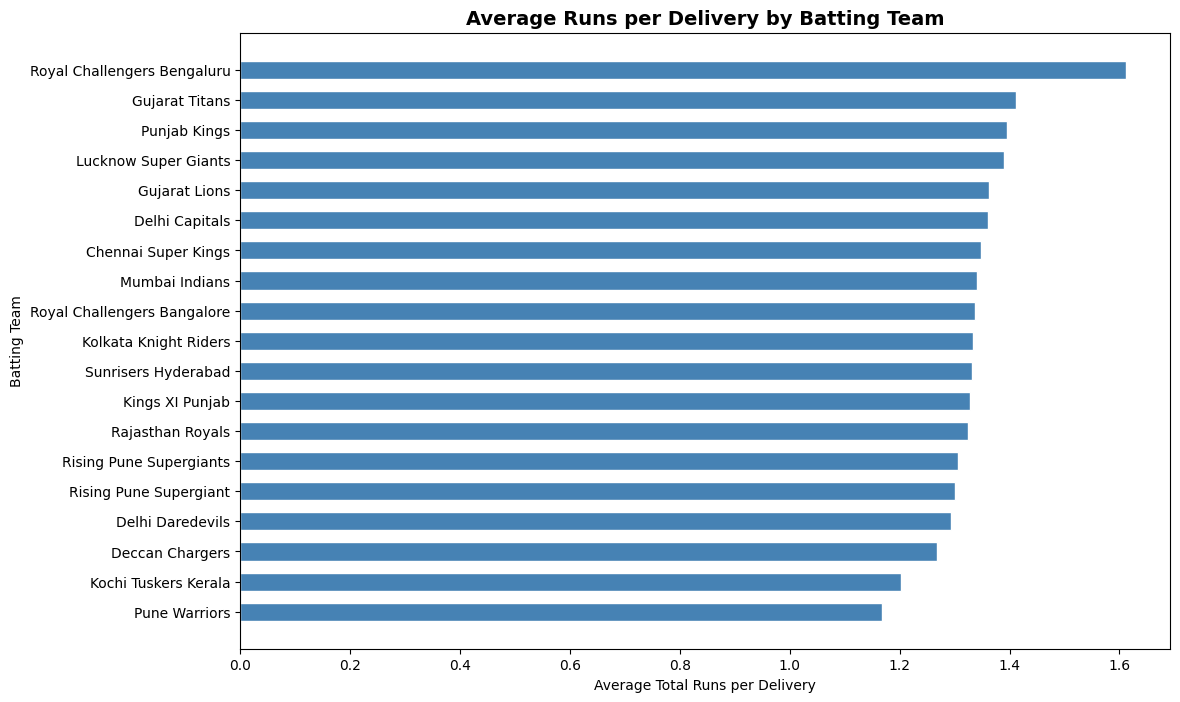

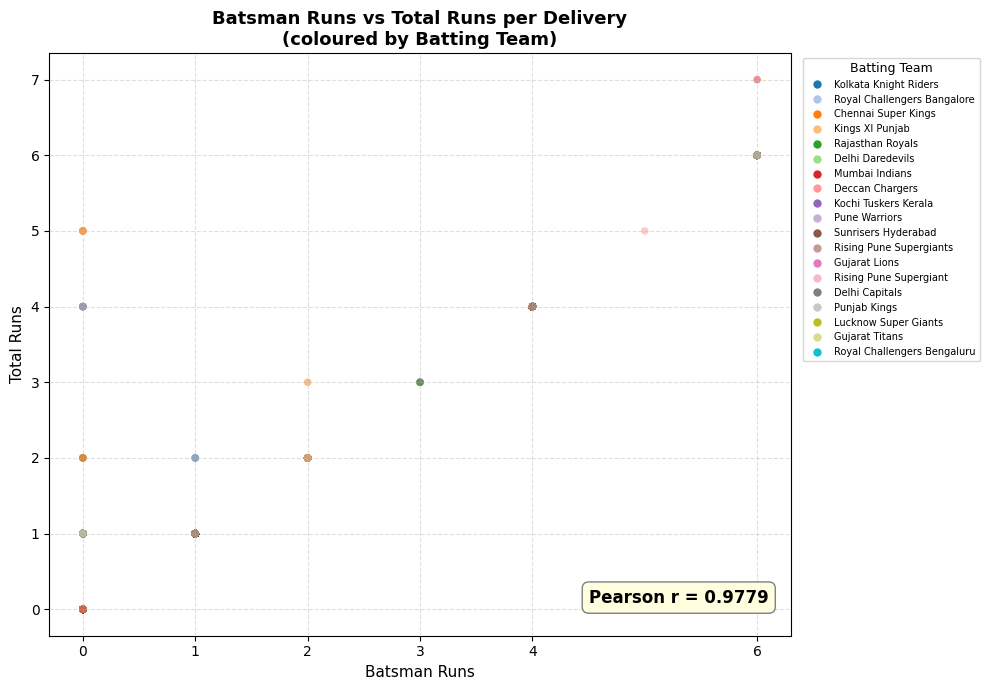

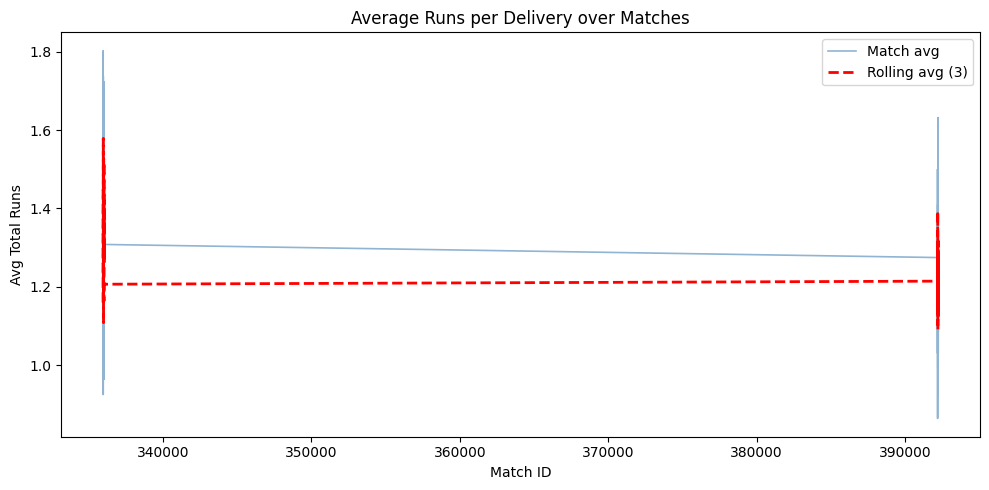

In [72]:
# NOTE: THESE ARE MY GRAPHS THAT I PLOTTED

# 1. Histogram: Distribution of total runs
runs = df['total_runs']

mean_val   = runs.mean()
median_val = runs.median()

plt.figure(figsize=(10, 5))
plt.hist(runs, bins = 30, color='orange', edgecolor='white')

plt.axvline(mean_val, color = 'red', lw = 2, label=f'Mean   = {mean_val:.2f}')
plt.axvline(median_val, color = 'black', lw = 2, label=f'Median = {median_val:.2f}')

plt.title('Distribution of Total Runs per Delivery', fontsize=14)
plt.xlabel('Total Runs')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Horizontal bar: Avg runs per batting team

team_avg = (df.groupby('batting_team')['total_runs'].mean().sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(team_avg.index, team_avg.values, color='steelblue', edgecolor='white', height=0.6)

ax.set_title('Average Runs per Delivery by Batting Team', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Total Runs per Delivery')
ax.set_ylabel('Batting Team')

# 3. Scatter: Batsman runs vs total runs
x = df['batsman_runs']
y = df['total_runs']

# Pearson correlation
corr = np.corrcoef(x, y)[0, 1]

# Map each batting team to a colour
teams = df['batting_team'].unique()
palette = plt.cm.tab20.colors
team_colour = {team: palette[i % 20] for i, team in enumerate(teams)}
colours = df['batting_team'].map(team_colour)

fig, ax = plt.subplots(figsize=(10, 7))

sample = df.sample(3000, random_state=42)
sample_colours = sample['batting_team'].map(team_colour)

ax.scatter(sample['batsman_runs'], sample['total_runs'],
           c=sample_colours, alpha=0.5, edgecolors='none', s=30)

ax.text(0.97, 0.05, f'Pearson r = {corr:.4f}',
        transform=ax.transAxes, fontsize=12, fontweight='bold',
        ha='right', va='bottom',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='grey'))

handles = [plt.Line2D([0], [0], marker='o', color='w',
                       markerfacecolor=team_colour[t], markersize=7, label=t)
           for t in teams]
ax.legend(handles=handles, title='Batting Team', bbox_to_anchor=(1.01, 1),
          loc='upper left', fontsize=7, title_fontsize=9)

ax.set_title('Batsman Runs vs Total Runs per Delivery\n(coloured by Batting Team)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Batsman Runs', fontsize=11)
ax.set_ylabel('Total Runs', fontsize=11)
ax.set_xticks([0, 1, 2, 3, 4, 6])
ax.set_yticks(sorted(df['total_runs'].unique()))
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 4. Line: Avg runs per match with rolling average

trend = df.groupby('match_id')['total_runs'].mean().reset_index()
trend.columns = ['match_id', 'avg_runs']
trend = trend.sort_values('match_id').head(100)

rolling = trend['avg_runs'].rolling(window=3).mean()

plt.figure(figsize=(10, 5))
plt.plot(trend['match_id'], trend['avg_runs'], color='steelblue', alpha=0.6, linewidth=1.2, label='Match avg')
plt.plot(trend['match_id'], rolling, color='red', linestyle='--', linewidth=2, label='Rolling avg (3)')
plt.title('Average Runs per Delivery over Matches')
plt.xlabel('Match ID')
plt.ylabel('Avg Total Runs')
plt.legend()
plt.tight_layout()
plt.show()

In [73]:
###

In [74]:
###

In [75]:
####### BUILDING THE MODELS #######

In [76]:
##### 1) LINEAR REGRESSION FROM SCRATCH #####

In [101]:
#FEATURE SELECTION and ENCODING

df['batter_avg']       = df.groupby('batter')['total_runs'].transform('mean')
df['bowler_avg']       = df.groupby('bowler')['total_runs'].transform('mean')
df['batting_team_avg'] = df.groupby('batting_team')['total_runs'].transform('mean')
df['bowling_team_avg'] = df.groupby('bowling_team')['total_runs'].transform('mean')

features = ['over', 'ball', 'inning', 'is_wicket', 'batter_avg', 'bowler_avg', 'batting_team_avg', 'bowling_team_avg',]
target   = 'total_runs'

data = df[features + [target]].dropna().values
np.random.shuffle(data)

X = data[:, :-1]
y = data[:, -1]

In [102]:
# TRAIN TEST SPLIT

split  = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [103]:
# STANDARDIZE DATA

mean = X_train.mean(axis=0)
std  = X_train.std(axis=0)

X_train_new = (X_train - mean) / std
X_test_new  = (X_test  - mean) / std

In [104]:
# ADD BIAS COLUMN

ones        = np.ones((X_train_new.shape[0], 1))
X_train_a   = np.hstack([ones, X_train_new])

ones_test   = np.ones((X_test_new.shape[0], 1))
X_test_a   = np.hstack([ones_test, X_test_new])

In [105]:
# SOLVE FOR β

beta = np.linalg.lstsq(X_train_a, y_train, rcond=None)[0]

In [106]:
# PREDICTION

y_pred = X_test_a @ beta

mse = np.mean((y_test - y_pred) ** 2)
ss_res = np.sum((y_test - y_pred) ** 2)
ss_tot = np.sum((y_test - y_test.mean()) ** 2)
r2  = 1 - ss_res / ss_tot

print(f"MSE : {mse:.4f}")
print(f"RMSE: {np.sqrt(mse):.4f}")
print(f"R²  : {r2:.4f}")

MSE : 2.5011
RMSE: 1.5815
R²  : 0.0581


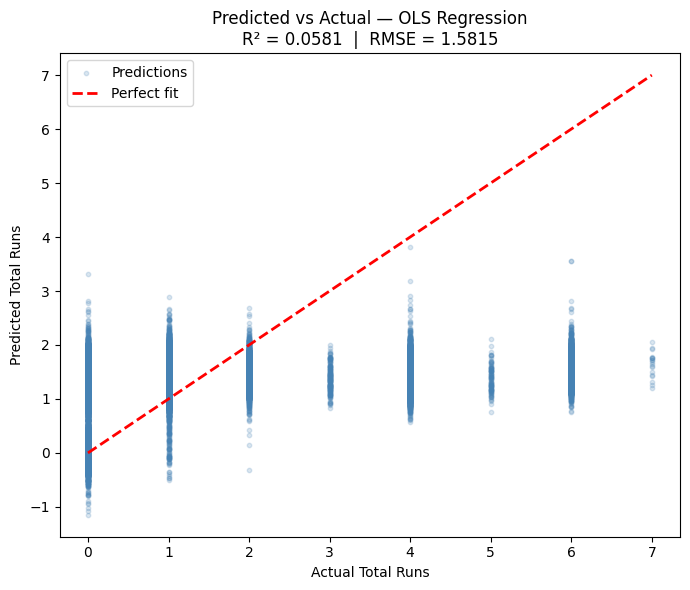

In [107]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(y_test, y_pred, alpha=0.2, s=10, color='steelblue', label='Predictions')

diag = [y_test.min(), y_test.max()]
ax.plot(diag, diag, color='red', linestyle='--', linewidth=2, label='Perfect fit')

ax.set_title(f'Predicted vs Actual — OLS Regression\nR² = {r2:.4f}  |  RMSE = {np.sqrt(mse):.4f}')
ax.set_xlabel('Actual Total Runs')
ax.set_ylabel('Predicted Total Runs')
ax.legend()
plt.tight_layout()
plt.show()

In [108]:
# Selecting features & dropping NaNs — we pick columns that plausibly influence how many runs are scored on a delivery.
# Any row with a missing value is removed so the matrix math doesn't break.

# Shuffling & splitting — we shuffle the rows randomly so train and test get a fair mix of all teams, overs, and match situations.

# Each feature gets rescaled to have mean 0 and standard deviation 1.

# β = (XᵀX)⁻¹Xᵀy is the closed-form solution that finds the exact β minimising the sum of squared errors without any iterations.


In [109]:
##### 2)LINEAR REGRESSION USING SKLEARN #####

In [110]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [111]:
X = df[features].values
y = df[target].values

indices = np.arange(len(X))
np.random.shuffle(indices)
split = int(0.8 * len(X))
train_idx, test_idx = indices[:split], indices[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

model   = LinearRegression()
model.fit(X_train, y_train)

y_pred  = model.predict(X_test)

mse  = mean_squared_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"MSE  : {mse:.4f}")
print(f"RMSE : {np.sqrt(mse):.4f}")
print(f"R²   : {r2:.4f}")

MSE  : 2.4854
RMSE : 1.5765
R²   : 0.0561


In [112]:
# Yes, the values obtained in this model(sk-learn) is quite close to the values obtained from our first model(scratch).

In [113]:
# batter_avg has the largest positive effect. ball (position within the over) has the smallest effect.

In [114]:
# Model doesn't predict 4 or 6 properly but moves towards predciting the mean.

In [115]:
# Reason is because cricket is an unpredictable game.
# Adding more features might help improve the accuracy of our model.
# Additionally we could add more features;
# For ex. as we know balls gives us least outcomes, we can divide it into two features 'PowerPlay'(0 < Over < 6), 'DeathOver'(16 < Over < 20) to get a much better prediction.